# Trace — Job Matching Model

**Two-stage retrieval:**
`paraphrase-multilingual-mpnet-base-v2` bi-encoder → cosine similarity (Stage 1) → heuristic weighted reranker (Stage 2)

**Three eval cases:**
1. Happy path — welder near Lekki
2. Multilingual retrieval — Pidgin generator post, Yaba
3. Rate + geography reranking — domestic worker, Lekki

All outputs are deterministic (seed=42, embeddings cached to disk).

In [ ]:
# Run once to install dependencies — skip if already installed
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'sentence-transformers', 'torch', '--quiet'])

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from training.job_match_synthetic import load_jobs, generate_workers, TEST_CASES
from training.job_match_engine import JobMatchEngine, WEIGHTS

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Load data

In [3]:
jobs    = load_jobs()
workers = generate_workers(n=200, seed=42)

print(f"Jobs:    {len(jobs)}  |  languages: {jobs['posted_language'].value_counts().to_dict()}")
print(f"Workers: {len(workers)}")
print(f"Cold-start (0 gigs): {(workers['completed_gigs'] == 0).sum()} "
      f"({100*(workers['completed_gigs']==0).mean():.0f}%)")
print()
print("Worker location distribution (top 8):")
print(workers['location_name'].value_counts().head(8).to_string())

# Persist to disk — commit these files and never regenerate on demo day
from training.job_match_synthetic import save_to_json
save_to_json(output_dir='../data') 

Jobs:    100  |  languages: {'en': 54, 'pcm': 43, 'ha': 1, 'ig': 1, 'yo': 1}
Workers: 200
Cold-start (0 gigs): 40 (20%)

Worker location distribution (top 8):
location_name
Festac               12
Agege                11
Apapa                10
Aba                  10
Abuja — Garki        10
Enugu GRA             9
Port Harcourt GRA     9
Victoria Island       9
Saved 100 jobs, 200 workers to ../data/
Cold-start workers: 40


## 2. Initialise engine + embed workers
First run: ~30s to encode 200 profiles. Every subsequent run: <1s from cache.

In [ ]:
engine = JobMatchEngine(model_name='paraphrase-multilingual-mpnet-base-v2')
engine.load_workers(workers, cache_path='../models/worker_embeddings.npy')
print("Engine ready.")

## 3. LaBSE sanity check — multilingual embeddings
Verify Hausa and Yoruba jobs produce meaningful embeddings before relying on them in the demo.
- Hausa tailoring ↔ English tailoring → **HIGH** (same domain, different language)
- Hausa tailoring ↔ English welding → **LOW** (different domain entirely)

In [ ]:
import numpy as np

def _embed_one(text):
    raw = engine.model.encode([text], convert_to_numpy=True)
    v = raw / np.linalg.norm(raw)
    return v[0]

hausa_tailoring   = jobs[jobs['job_id'] == 'job_011'].iloc[0]
english_tailoring = jobs[jobs['job_id'] == 'job_009'].iloc[0]
english_welding   = jobs[jobs['job_id'] == 'job_001'].iloc[0]
yoruba_painting   = jobs[jobs['job_id'] == 'job_032'].iloc[0]

e_ha   = _embed_one(f"{hausa_tailoring['title']}. {hausa_tailoring['description']}")
e_en_t = _embed_one(f"{english_tailoring['title']}. {english_tailoring['description']}")
e_en_w = _embed_one(f"{english_welding['title']}. {english_welding['description']}")
e_yo   = _embed_one(f"{yoruba_painting['title']}. {yoruba_painting['description']}")

checks = [
    ('Hausa tailoring ↔ English tailoring', float(e_ha @ e_en_t),  'HIGH', lambda s: s > 0.55),
    ('Hausa tailoring ↔ English welding  ', float(e_ha @ e_en_w),  'LOW',  lambda s: s < 0.50),
    ('Yoruba painting  ↔ English tailoring', float(e_yo @ e_en_t), 'MED',  lambda s: 0.30 < s < 0.80),
    ('Yoruba painting  ↔ English welding  ', float(e_yo @ e_en_w), 'LOW',  lambda s: s < 0.55),
]

all_pass = True
for label, score, expectation, test in checks:
    ok = test(score)
    all_pass = all_pass and ok
    print(f"{'✓' if ok else '✗ FAIL'}  {label}  (expect {expectation})  →  {score:.3f}")

print()
print("Multilingual embeddings look good — safe to demo." if all_pass
      else "⚠  One or more checks failed — investigate before the pitch.")

## 4. Test case 1 — Happy path (welder near Lekki)

In [6]:
hero = TEST_CASES[0]
job  = jobs[jobs['job_id'] == hero['job_id']].iloc[0].to_dict()

print(f"Job:         {job['title']}")
print(f"Location:    {job['location_name']}")
print(f"Budget:      ₦{job['budget_naira']:,}/day")
print(f"Language:    {job['posted_language']}")
print(f"\nDescription: {job['description']}")
print(f"\nExpected: {hero['description']}")

Job:         Welder needed for security gate fabrication
Location:    Lekki Phase 1
Budget:      ₦15,000/day
Language:    en

Description: We need an experienced welder to fabricate a security gate and perimeter fence for our compound. Mild steel work, own welding machine required. Minimum 5 years experience. Job site in Lekki Phase 1.

Expected: Welder in Lekki Phase 1, ₦15k/day. Top-5 should be welders near Lekki, rate ≤ ₦15k, high completion.


In [7]:
results1 = engine.match(job, top_k=5)

display_cols = [
    'name', 'location_name', 'distance_km', 'daily_rate_naira',
    'completed_gigs', 'kudiscore_tier',
    'semantic_score', 'location_score', 'performance_score', 'rate_score', 'final_score',
]
display_cols = [c for c in display_cols if c in results1.columns]

(results1[display_cols]
    .assign(daily_rate_naira=results1['daily_rate_naira'].apply(lambda x: f'₦{x:,}'))
    .rename(index=lambda i: i + 1))

,name,location_name,distance_km,daily_rate_naira,completed_gigs,kudiscore_tier,semantic_score,location_score,performance_score,rate_score,final_score
1,Obi,Lekki Phase 1,1.110,"₦11,244",47,gold,0.602,1.000,0.855,1.000,0.779
2,Adeola,Lekki Phase 1,1.600,"₦4,816",83,gold,0.544,1.000,0.986,1.000,0.770
3,Bayo,Lekki Phase 1,1.540,"₦12,828",184,gold,0.539,1.000,0.914,1.000,0.757
4,Musa,Lekki Phase 1,2.500,"₦5,223",188,silver,0.543,1.000,0.835,1.000,0.747
5,Adebayo,Ajah,4.420,"₦17,313",38,gold,0.577,1.000,0.842,0.846,0.742


## 5. Test case 2 — Multilingual retrieval (Pidgin generator post, Yaba)

In [8]:
hero2 = TEST_CASES[1]
job2  = jobs[jobs['job_id'] == hero2['job_id']].iloc[0].to_dict()

print(f"Job (Pidgin): {job2['title']}")
print(f"Description:  {job2['description']}")
print(f"\nExpected: {hero2['description']}")
print()

results2 = engine.match(job2, top_k=5)
display_cols2 = [c for c in display_cols if c in results2.columns]
(results2[display_cols2]
    .assign(daily_rate_naira=results2['daily_rate_naira'].apply(lambda x: f'₦{x:,}'))
    .rename(index=lambda i: i + 1))

Job (Pidgin): Person wey sabi fix gen for my shop for Yaba
Description:  My FG Wilson generator dey give problem since morning. E no dey start at all. I need technician wey sabi diesel gen come check am for Yaba. Make e come with diagnostic tools.

Expected: Pidgin post about a faulty generator in Yaba. Top-5 should be generator/electrical workers near Yaba — even if their bios are in English.



,name,location_name,distance_km,daily_rate_naira,completed_gigs,kudiscore_tier,semantic_score,location_score,performance_score,rate_score,final_score
1,Prosper,Ajah,27.270,"₦7,391",105,silver,0.595,0.850,0.839,1.000,0.743
2,Adeola,Agege,11.610,"₦8,191",135,silver,0.511,0.850,0.758,0.976,0.686
3,Obinna,Yaba,2.430,"₦5,796",150,silver,0.431,1.000,0.786,1.000,0.684
4,Hadiza,Isolo,7.040,"₦7,374",138,bronze,0.422,1.000,0.811,1.000,0.683
5,Maryam,Maryland,5.990,"₦10,317",39,bronze,0.548,1.000,0.654,0.710,0.678


## 6. Test case 3 — Rate + geography reranking (domestic worker, Lekki)

In [9]:
hero3 = TEST_CASES[2]
job3  = jobs[jobs['job_id'] == hero3['job_id']].iloc[0].to_dict()

print(f"Job:         {job3['title']}")
print(f"Budget:      ₦{job3['budget_naira']:,}/day")
print(f"Description: {job3['description']}")
print(f"\nExpected: {hero3['description']}")
print()

results3 = engine.match(job3, top_k=5)
display_cols3 = [c for c in display_cols if c in results3.columns]
(results3[display_cols3]
    .assign(daily_rate_naira=results3['daily_rate_naira'].apply(lambda x: f'₦{x:,}'))
    .rename(index=lambda i: i + 1))

Job:         Domestic worker — Lekki Phase 1, full-time live-out
Budget:      ₦4,000/day
Description: We are looking for a reliable, experienced domestic worker for our home in Lekki Phase 1. Full-time, Monday to Saturday. Duties include cooking, cleaning, laundry, and light childcare. ₦88,000/month (≈ ₦4,000/day).

Expected: Full-time domestic worker in Lekki, ₦80k/month (≈₦3,600/day). Rate cap is tight — workers asking more should rank below lower-rated but cheaper ones.



,name,location_name,distance_km,daily_rate_naira,completed_gigs,kudiscore_tier,semantic_score,location_score,performance_score,rate_score,final_score
1,Lawal,Lekki Phase 1,2.480,"₦2,678",10,silver,0.693,1.000,0.631,1.000,0.791
2,Musa,Lekki Phase 1,2.500,"₦5,223",188,silver,0.660,1.000,0.835,0.694,0.759
3,Adeola,Lekki Phase 1,1.600,"₦4,816",83,gold,0.539,1.000,0.986,0.796,0.737
4,Grace,Ikorodu,18.200,"₦2,721",25,silver,0.576,0.850,0.737,1.000,0.719
5,Lawal,Gbagada,26.340,"₦2,632",170,silver,0.507,0.850,0.859,1.000,0.702


## 7. Score breakdown chart — Test case 1 (Welder, Lekki)

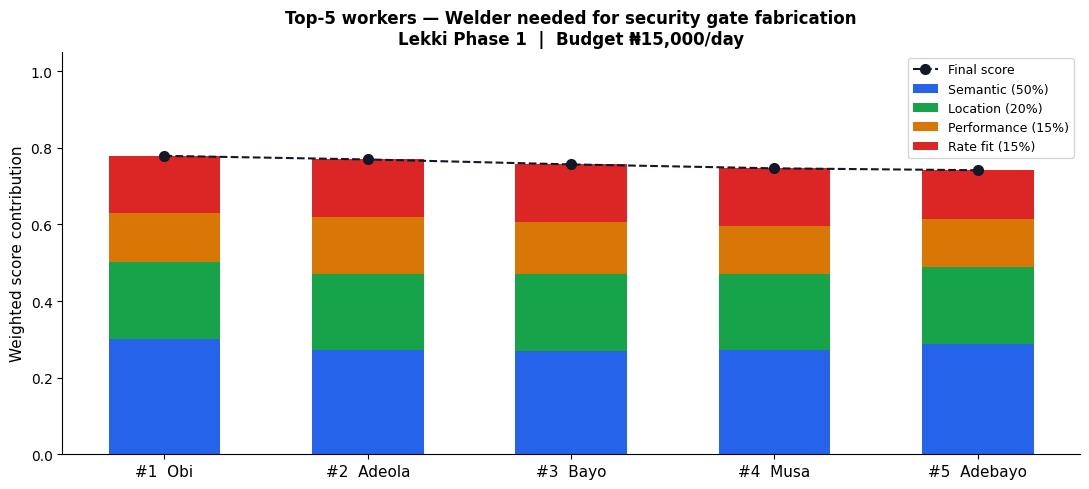

Saved → results/job_match.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

names       = results1['name'].tolist()
score_cols  = ['semantic_score', 'location_score', 'performance_score', 'rate_score']
weight_keys = ['semantic', 'location', 'performance', 'rate']
colors      = ['#2563EB', '#16A34A', '#D97706', '#DC2626']
labels      = ['Semantic (50%)', 'Location (20%)', 'Performance (15%)', 'Rate fit (15%)']

x      = np.arange(len(names))
bottom = np.zeros(len(names))

for col, wkey, color, label in zip(score_cols, weight_keys, colors, labels):
    if col not in results1.columns:
        continue
    contribution = results1[col].values * WEIGHTS[wkey]
    ax.bar(x, contribution, bottom=bottom, color=color, label=label, width=0.55)
    bottom += contribution

ax.plot(x, results1['final_score'].values, 'o--', color='#111827',
        linewidth=1.5, markersize=7, label='Final score', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f"#{i+1}  {n}" for i, n in enumerate(names)], fontsize=11)
ax.set_ylabel('Weighted score contribution', fontsize=11)
ax.set_title(
    f'Top-5 workers — {job["title"]}\n{job["location_name"]}  |  Budget ₦{job["budget_naira"]:,}/day',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/job_match.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/job_match.png")